In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
pre_opsin = ['AE_344','AE_346','AE_367']
pre_control = ['AE_418','AE_498','AE_351','AE_350','AE_359'] 

In [3]:
with open(os.path.join('..','..','Source Data Files','Cov_Mats_ClusteredPre.pickle'), 'rb') as f:
    Data_Exp = pickle.load(f)
# mask = np.isin(Data_Exp.sessions,EnumSessionOps)
Data_Exp.sessions = np.array(Data_Exp.sessions,dtype=str)
Data_Exp.phases = np.array(Data_Exp.phases,dtype=str)
Data_Exp.cov_mats = np.array(Data_Exp.cov_mats,dtype='object')
Data_Exp.cov_mats_CR = np.array(Data_Exp.cov_mats_CR,dtype='object')
Data_Exp.cov_mats_NCR = np.array(Data_Exp.cov_mats_NCR,dtype='object')
Data_Exp.cov_mats_CRNCR = np.array(Data_Exp.cov_mats_CRNCR,dtype='object')

In [4]:
Data_Control = SimpleNamespace()
with open(os.path.join('..','..','Source Data Files','Cov_Mats_ClusteredPreAllTrials.pickle'), 'rb') as f:
    Data_OpsCon = pickle.load(f)
Data_Control.sessions = np.array(Data_OpsCon.sessions,dtype=str)
Data_Control.phases = np.array(Data_OpsCon.phases,dtype=str)
Data_Control.cov_mats = np.array(Data_OpsCon.cov_mats,dtype='object')
Data_Control.cov_mats_CR = np.array(Data_OpsCon.cov_mats_CR,dtype='object')
Data_Control.cov_mats_NCR = np.array(Data_OpsCon.cov_mats_NCR,dtype='object')
Data_Control.cov_mats_CRNCR = np.array(Data_OpsCon.cov_mats_CRNCR,dtype='object')

In [5]:
def bootstrap_dimensionality_all_vars(cov_mats,n_frac=0.5,B=200):
    mask = [c.size>0 for c in cov_mats]
    cov_mats = cov_mats[mask]
    
    d_GT_list = []
    d_num_list = []
    d_denom_list = []
    
    for idx_B in range(B):
        n = len(cov_mats)
        sample = np.random.choice(cov_mats,n)
        
        all_vars = []
        all_covars = []
        for cov in sample:
            if type(cov) is float:
                continue
            cov = np.array(cov)
            if len(cov.shape) < 2:
                continue
            assert cov.shape[0] == cov.shape[1]
            n_clust = cov.shape[0]
            
            new_n = int(n_clust*n_frac)
            if new_n < 1:
                continue
            mask = range(new_n)
            cov= np.array([c[mask] for c in cov[mask]])

            this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
            this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
            all_vars.append(this_vars)
            all_covars.append(this_covars)
        all_vars = np.concatenate(all_vars)
        all_covars = np.concatenate(all_covars)

        n = len(all_vars)
        avg_sq_vars = np.nanmean(all_vars**2)
        avg_sq_covars = np.nanmean(all_covars**2)
        avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
        d_GT = avg_pred_covars/avg_sq_covars
        d_GT_list.append(d_GT)
        d_num_list.append(avg_pred_covars)
        d_denom_list.append(avg_sq_covars)
        
    d_GT_list = ilep.rmnan(d_GT_list)
    d_GT_estimate = np.mean(d_GT_list)
    SEM_d_GT_estimate = sem(d_GT_list)

    all_vars = []
    all_covars = []
    for cov in cov_mats:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        new_n = int(n_clust*n_frac)
        if new_n < 1:
            continue
        mask = range(new_n)
        cov= np.array([c[mask] for c in cov[mask]])

        this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
        this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
        all_vars.append(this_vars)
        all_covars.append(this_covars)
    all_vars = np.concatenate(all_vars)
    all_covars = np.concatenate(all_covars)
        
    all_vars = ilep.rmnan(all_vars)
    all_covars = ilep.rmnan(np.abs(all_covars)) #abs because only the squared value matters for the calculation
        
    return d_GT_estimate,SEM_d_GT_estimate,  np.mean(all_vars),sem(all_vars),   np.mean(all_covars),sem(all_covars)

In [6]:
def bootstrap_dimensionality_all_vars_median_IQR(cov_mats,n_frac=0.5,B=200):
    mask = [c.size>0 for c in cov_mats]
    cov_mats = cov_mats[mask]
    
    d_GT_list = []
    d_num_list = []
    d_denom_list = []
    
    for idx_B in range(B):
        n = len(cov_mats)
        sample = np.random.choice(cov_mats,n)
#         sample = cov_mats
        
        all_vars = []
        all_covars = []
        for cov in sample:
            if type(cov) is float:
                continue
            cov = np.array(cov)
            if len(cov.shape) < 2:
                continue
            assert cov.shape[0] == cov.shape[1]
            n_clust = cov.shape[0]
            
            new_n = int(n_clust*n_frac)
            if new_n < 1:
                continue
            mask = range(new_n)
            cov= np.array([c[mask] for c in cov[mask]])

            this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
            this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
            all_vars.append(this_vars)
            all_covars.append(this_covars)
        all_vars = np.concatenate(all_vars)
        all_covars = np.concatenate(all_covars)

        n = len(all_vars)
        avg_sq_vars = np.nanmean(all_vars**2)
        avg_sq_covars = np.nanmean(all_covars**2)
        avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
        d_GT = avg_pred_covars/avg_sq_covars
        d_GT_list.append(d_GT)
        d_num_list.append(avg_pred_covars)
        d_denom_list.append(avg_sq_covars)
        
    d_GT_list = ilep.rmnan(d_GT_list)
    d_GT_estimate = np.median(d_GT_list)
    d_GT_Q1_estimate = np.percentile(d_GT_list,25)
    d_GT_Q3_estimate = np.percentile(d_GT_list,75)
    SEM_d_GT_estimate = sem(d_GT_list)

    all_vars = []
    all_covars = []
    for cov in cov_mats:
        if type(cov) is float:
            continue
        cov = np.array(cov)
        if len(cov.shape) < 2:
            continue
        assert cov.shape[0] == cov.shape[1]
        n_clust = cov.shape[0]

        new_n = int(n_clust*n_frac)
        if new_n < 1:
            continue
        mask = range(new_n)
        cov= np.array([c[mask] for c in cov[mask]])

        this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
        this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
        all_vars.append(this_vars)
        all_covars.append(this_covars)
    all_vars = np.concatenate(all_vars)
    all_covars = np.concatenate(all_covars)
        
    all_vars = ilep.rmnan(all_vars)
    all_covars = ilep.rmnan(np.abs(all_covars)) #abs because only the squared value matters for the calculation

    return d_GT_estimate,d_GT_Q1_estimate,d_GT_Q3_estimate,  np.median(all_vars),np.percentile(all_vars,25),np.percentile(all_vars,75),   np.median(all_covars),np.percentile(all_covars,25),np.percentile(all_covars,75)

(9,)
(8,)
(8,)


C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\368650127.py:39: RuntimeWarning: Mean of empty slice
  avg_sq_vars = np.nanmean(all_vars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\368650127.py:40: RuntimeWarning: Mean of empty slice
  avg_sq_covars = np.nanmean(all_covars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\368650127.py:41: RuntimeWarning: Mean of empty slice
  avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])


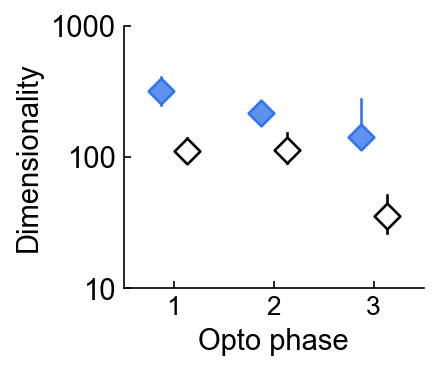

In [7]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

        
fig,ax = make_axis_size(2, 1.75, left=.3, bottom=.3, right=0, top=0)
sz=76
s_wid=1.25
offset=0.13
switch_offset=0

################################################################################################################################################################

phases = ['pre early','pre late','pre expert']
for idx,phase in enumerate(phases):
    phase_mask = np.char.equal(Data_Exp.phases,phase)
    phase_mask_control = np.char.equal(Data_Control.phases,phase)

    cov_mats = np.array(Data_Exp.cov_mats_NCR,dtype='object')[phase_mask]
    print(cov_mats.shape)
    M,Q1,Q3,Mnum,Q1num,Q3num,Mden,Q1den,Q3den = bootstrap_dimensionality_all_vars_median_IQR(cov_mats,n_frac = 1,B=2000)
    ax.scatter(idx-offset,np.log10(M),ec=LASER_COLOR,fc=LIGHT_LASER,s=sz,marker='D',lw=s_wid,zorder=4)
    ax.plot([idx-offset,idx-offset],[np.log10(Q1),np.log10(Q3)],c=LASER_COLOR,lw=s_wid,zorder=3)

    cov_mats = np.array(Data_Control.cov_mats_NCR,dtype='object')[phase_mask_control]
    M,Q1,Q3,Mnum,Q1num,Q3num,Mden,Q1den,Q3den = bootstrap_dimensionality_all_vars_median_IQR(cov_mats,n_frac = 1,B=2000)
    ax.scatter(idx+offset,np.log10(M),fc='white',ec='k',s=sz,lw=s_wid,marker='D',zorder=10)
    ax.plot([idx+offset,idx+offset],[np.log10(Q1),np.log10(Q3)],c='k',lw=s_wid,zorder=9)
    
ax.set_ylim([1,3])
ax.set_yticks([1,2,3])
ax.set_yticklabels(['10','100','1000'])
ax.set_ylabel('Dimensionality')
    
labels = ['1','2','3']
ax.set_xlim([-0.5,2.5])
ax.set_xticks([0,1,2])
ax.set_xticklabels(labels)
ax.set_xlabel('Opto phase')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
artists = []
# fig.savefig(os.path.join('..','..','Figures','Figure 4c Top Left.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

1.4783078696735978
0.07083082227025084
1.4669295368134614
0.03776795317975885
2.28162084324348
0.1912468404576077


C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\1135516248.py:39: RuntimeWarning: Mean of empty slice
  avg_sq_vars = np.nanmean(all_vars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\1135516248.py:40: RuntimeWarning: Mean of empty slice
  avg_sq_covars = np.nanmean(all_covars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\1135516248.py:41: RuntimeWarning: Mean of empty slice
  avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])


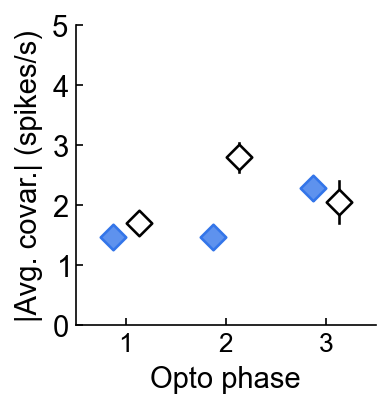

In [8]:
# with open('D:\\Cov_Mats_Opto_On.pickle', 'rb') as f:
#     Data_On = pickle.load(f)    
# with open('D:\\Cov_Mats.pickle', 'rb') as f:
#     Data = pickle.load(f)
    
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(2, 2, left=.3, bottom=.3, right=0, top=0)
sz=75
s_wid=1.25
offset=0.13
switch_offset=0

################################################################################################################################################################

phases = ['pre early','pre late','pre expert']
for idx,phase in enumerate(phases):
    phase_mask = np.char.equal(Data_Exp.phases,phase)
    phase_mask_control = np.char.equal(Data_Control.phases,phase)
    
    cov_mats = np.array(Data_Exp.cov_mats_NCR,dtype='object')[phase_mask]
    M,SEM,Mnum,SEMnum,Mden,SEMden = bootstrap_dimensionality_all_vars(cov_mats,n_frac = 1,B=2000)
    ax.scatter(idx-offset,(Mden),ec=LASER_COLOR,fc=LIGHT_LASER ,s=sz,lw=s_wid,marker='D',zorder=10)
    ax.plot([idx-offset,idx-offset],[(Mden-SEMden),(Mden+SEMden)],c=LASER_COLOR,lw=s_wid)
    
    cov_mats = np.array(Data_Control.cov_mats_NCR,dtype='object')[phase_mask_control]
    M,SEM,Mnum,SEMnum,Mden,SEMden = bootstrap_dimensionality_all_vars(cov_mats,n_frac = 1,B=2000)
    ax.scatter(idx+offset,(Mden),ec='k',fc='white',s=sz,marker='D',lw=s_wid,zorder=10)
    ax.plot([idx+offset,idx+offset],[(Mden-SEMden),(Mden+SEMden)],c='k',lw=s_wid)
    
ax.set_ylim([0,5])
ax.set_yticks([0,1,2,3,4,5])
ax.set_ylabel('|Avg. covar.| (spikes/s)')
    
labels = ['1','2','3']
ax.set_xlim([-0.5,2.5])
ax.set_xticks([0,1,2])
ax.set_xticklabels(labels)
ax.set_xlabel('Opto phase')

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass
    
artists = []
# fig.savefig(os.path.join('..','..','Figures','Figure 4c Bottom Left.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [9]:
def bootstrap_dimm_stats(cov_mats_1,cov_mats_2,B=250000,n_frac=1):
    
    d_GT_list_1 = []
    d_num_list_1 = []
    d_den_list_1 = []
    for idx_B in range(B):
        try:
            n = len(cov_mats_1)
            sample = np.random.choice(cov_mats_1,n)

            all_vars = []
            all_covars = []
            for cov in sample:
                if type(cov) is float:
                    continue
                cov = np.array(cov)
                if len(cov.shape) < 2:
                    continue
                assert cov.shape[0] == cov.shape[1]
                n_clust = cov.shape[0]

                new_n = int(n_clust*n_frac)
                if new_n < 1:
                    continue
                mask = range(new_n)
                cov= np.array([c[mask] for c in cov[mask]])

                this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
                this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
                all_vars.append(this_vars)
                all_covars.append(this_covars)
            all_vars = np.concatenate(all_vars)
            all_covars = np.concatenate(all_covars)
            
            n = len(all_vars)
            avg_sq_vars = np.nanmean(all_vars**2)
            avg_sq_covars = np.nanmean(all_covars**2)
            avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])
            
            d_GT = avg_pred_covars/avg_sq_covars
            d_GT_list_1.append(d_GT)
            d_num_list_1.append(avg_pred_covars)
            d_den_list_1.append(avg_sq_covars)
        except Exception as e:
            print(f"L: {e}")
            d_GT_list_1.append(np.nan)
            d_num_list_1.append(np.nan)
            d_den_list_1.append(np.nan)
    
    d_GT_list_2 = []
    d_num_list_2 = []
    d_den_list_2 = []
    for idx_B in range(B):
        try:
            n = len(cov_mats_2)
            sample = np.random.choice(cov_mats_2,n)

            all_vars = []
            all_covars = []
            for cov in sample:
                if type(cov) is float:
                    continue
                cov = np.array(cov)
                if len(cov.shape) < 2:
                    continue
                assert cov.shape[0] == cov.shape[1]
                n_clust = cov.shape[0]

                new_n = int(n_clust*n_frac)
                if new_n < 1:
                    continue
                mask = range(new_n)
                cov= np.array([c[mask] for c in cov[mask]])

                this_vars = cov[np.eye(new_n,new_n,dtype='bool')]
                this_covars = cov[~np.eye(new_n,new_n,dtype='bool')]
                all_vars.append(this_vars)
                all_covars.append(this_covars)
            all_vars = np.concatenate(all_vars)
            all_covars = np.concatenate(all_covars)

            n = len(all_vars)
            avg_sq_vars = np.nanmean(all_vars**2)
            avg_sq_covars = np.nanmean(all_covars**2)
            avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])

            d_GT = avg_pred_covars/avg_sq_covars
            d_GT_list_2.append(d_GT)
            d_num_list_2.append(avg_pred_covars)
            d_den_list_2.append(avg_sq_covars)
        except:
            d_GT_list_2.append(np.nan)
            d_num_list_2.append(np.nan)
            d_den_list_2.append(np.nan)
        
        
        
    #Two-sided test
    X,Y = ilep.paired_rmnan(d_GT_list_1,d_GT_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot1 = min(pX,pY)*2
    
    X,Y = ilep.paired_rmnan(d_num_list_1,d_num_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot2 = min(pX,pY)*2
    
    X,Y = ilep.paired_rmnan(d_den_list_1,d_den_list_2)
    diffs = (np.array(X) - np.array(Y))
    pY = 1 - np.mean(np.greater(diffs,0))
    pX = 1 - np.mean(np.less(diffs,0))
    pboot3 = min(pX,pY)*2
    return pboot1,pboot2,pboot3

In [12]:
phases = ['pre early','pre late','pre expert']
B = 2500#0

phases1 = Data_Exp.phases
phases2 = Data_Control.phases

phase_mask1 = np.char.equal(phases1,'pre early')
phase_mask2 = np.char.equal(phases2,'pre early')
cov1 = np.array(Data_Exp.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data_Control.cov_mats_NCR)[phase_mask2]
p1,pp1,ppp1 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(phases1,'pre late')
phase_mask2 = np.char.equal(phases2,'pre late')
cov1 = np.array(Data_Exp.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data_Control.cov_mats_NCR)[phase_mask2]
p2,pp2,ppp2 = bootstrap_dimm_stats(cov1,cov2,B=B)

phase_mask1 = np.char.equal(phases1,'pre expert')
phase_mask2 = np.char.equal(phases2,'pre expert')
cov1 = np.array(Data_Exp.cov_mats_NCR)[phase_mask1]
cov2 = np.array(Data_Control.cov_mats_NCR)[phase_mask2]
p3,pp3,ppp3 = bootstrap_dimm_stats(cov1,cov2,B=B)

pvals = [p1,p2,p3]
_,p_corr = pg.multicomp(pvals,method='fdr_bh')
print('NCR Dimensionality')
print(f'Phase 1: p={p_corr[0]}')
print(f'Phase 2: p={p_corr[1]}')
print(f'Phase 3: p={p_corr[2]}\n')


pppvals = [ppp1,ppp2,ppp3]
_,ppp_corr = pg.multicomp(pppvals,method='fdr_bh')
print('NCR Covariance')
print(f'Phase 1: p={ppp_corr[0]}')
print(f'Phase 2: p={ppp_corr[1]}')
print(f'Phase 3: p={ppp_corr[2]}')

C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\2062419837.py:83: RuntimeWarning: Mean of empty slice
  avg_sq_vars = np.nanmean(all_vars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\2062419837.py:84: RuntimeWarning: Mean of empty slice
  avg_sq_covars = np.nanmean(all_covars**2)
C:\Users\abrah\AppData\Local\Temp\ipykernel_61364\2062419837.py:85: RuntimeWarning: Mean of empty slice
  avg_pred_covars = np.nanmean(np.outer(all_vars,all_vars)[~np.eye(n,n,dtype='bool')])


NCR Dimensionality
Phase 1: p=0.14639999999999986
Phase 2: p=0.1633960752903485
Phase 3: p=0.1633960752903485

NCR Covariance
Phase 1: p=0.31477773327993597
Phase 2: p=0.019199999999999884
Phase 3: p=0.31477773327993597
